In [1]:
from multiprocess import set_start_method
set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [2]:

import torch
from scipy import stats
import numpy as np

import numpy as np
from scipy import stats
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import os


In [3]:
MODEL = "OLMo-2-0425-1B_tulu-v2-sft-mixture"

In [4]:
indices_dir = os.path.join("./models", MODEL, "indices")
# indices = [
#     (*f.split("_")[:-1], torch.load(os.path.join(indices_dir, f)))
#     for f in os.listdir(indices_dir)
#     if os.path.isfile(os.path.join(indices_dir, f)) and f.endswith((".pt"))
# ]
# indices = [(int(i.replace("iter","")),t, [int(j) for j in ind]) for i,t, ind in indices]
# df = pd.DataFrame(indices, columns=["interation", "subset", "indices"])
# df

In [5]:
from influence_estimation.data_inf import DataInfEstimator
from influence_estimation.less_inf import LESSEstimator
from datasets import load_dataset


# base_model_path = "distilbert/distilgpt2"
base_model_path = "allenai/OLMo-2-0425-1B"
# adapter_path = "/srv/home/users/loriss21cs/cfe/models/distilgpt2_tulu-v2-sft-mixture"
adapter_path = "/srv/home/users/loriss21cs/cfe/models/OLMo-2-0425-1B_tulu-v2-sft-mixture"

train_dataset = load_dataset("allenai/tulu-v2-sft-mixture", split="train")#.shuffle(seed=0).select(range(20))





test_dataset = load_dataset("allenai/tulu-v2-sft-mixture", split="train").shuffle(seed=0).select(range(100))



[INFO] PyTorch version 2.7.0+cu126 available.


In [6]:
from itertools import chain

class Experiment:
    def __init__(self, full_train_dataset, model_path="./models/OLMo-2-0425-1B_tulu-v2-sft-mixture"):
        self.full_train_dataset = full_train_dataset
        def add_index(example, idx):
            example["indices"] = idx
            return example
        self.full_train_dataset = self.full_train_dataset.map(add_index, with_indices=True, num_proc=10)
            
        self.model_path = model_path
        self.train_indices_path = os.path.join(model_path, "indices")
        self.load_indices()
        self._coreset_dataset = None  # Private backing field
        self._train_dataset = None  # Private backing field
        self.__name__ = os.path.basename(self.model_path)
    def load_indices(self):
        indices = [
        (*f.split("_")[:-1], torch.load(os.path.join(self.train_indices_path, f)))
            for f in os.listdir(indices_dir)
                if os.path.isfile(os.path.join(indices_dir, f)) and f.endswith((".pt"))
        ]
        indices = [(int(i.replace("iter","")),t, [int(j) for j in ind]) for i,t, ind in indices]
        df = pd.DataFrame(indices, columns=["iteration", "subset", "indices"]).sort_values(by="iteration")        
        self.train_indices = {
            subset: {
                iteration: group[group["subset"] == subset]["indices"].tolist()[0]
                for iteration, group in df.groupby("iteration")
            }
            for subset in df["subset"].unique()  
        }
    @property
    def coreset_dataset(self):
        if self._coreset_dataset is None:           
            self._coreset_dataset = self.full_train_dataset.select(
                set(chain.from_iterable(self.train_indices["selected"].values()))
            )
        return self._coreset_dataset
    @property
    def train_dataset(self):
        if self._train_dataset is None:
            self._train_dataset = self.full_train_dataset.select(
                set(chain.from_iterable(self.train_indices["full"].values()))
            )
        return self._train_dataset
        

In [7]:
experiments = [
    # Experiment(train_dataset, model_path="./models/OLMo-2-0425-1B_tulu-v2-sft-mixture"),
    Experiment(train_dataset, model_path="./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_0p5"),
    Experiment(train_dataset, model_path="./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_0p25"),
    Experiment(train_dataset, model_path="./models/OLMo-2-0425-1B_tulu-v2-sft-mixture_1p0")   
] 


In [8]:
estimators = [
    # LESSEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=False),
    # LESSEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=True),
    LESSEstimator(base_model_path, adapter_path, experiments[0].train_dataset, test_dataset),
    LESSEstimator(base_model_path, adapter_path, experiments[0].coreset_dataset, test_dataset),
    LESSEstimator(base_model_path, adapter_path, experiments[1].coreset_dataset, test_dataset),
    LESSEstimator(base_model_path, adapter_path, experiments[2].coreset_dataset, test_dataset),
    # LESSEstimator(base_model_path, adapter_path, train_dataset, test_dataset,normalize=False)
]

In [9]:
import torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from abc import ABC, abstractmethod
from ignite.engine import Engine, Events
from ignite.handlers import ModelCheckpoint, EarlyStopping
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator
torch.manual_seed(42)
cos = torch.nn.CosineSimilarity(dim=0, eps=1e-6)

device = "cuda"

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed



import torch
import torch.nn as nn
import torch.nn.functional as F
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping


class Optimizer(ABC, nn.Module):
    def __init__(self, train_grads, test_grad, device=None, lr=1e-3):
        super().__init__()
        self.device = device
        self.lr = lr
        self.train_grads = train_grads.to(self.device)
        self.test_grad = test_grad.to(self.device)

        n_train = self.train_grads.shape[0]
        with torch.no_grad():
            self.solution = torch.linalg.lstsq(self.train_grads.T.to(device), self.test_grad.view(-1).to(device)).solution
            # print("self.solution",self.solution,flush=True)
            mask = torch.empty(n_train,device=device).bernoulli_(0.5)
            # print("sum", sum(mask),mask.shape)
            random_values = torch.rand_like(self.solution)  

            combined = mask * self.solution + (1 - mask) * random_values

            self.factors = nn.Parameter(combined)#torch.clamp(combined, min=0))

            # self.factors = nn.Parameter(torch.randn(n_train, device=self.device))
            # self.factors = nn.Parameter(torch.zeros(n_train, device=self.device))



        
        self.best_factors = None
        self._score = None
        self.steps_no_improve = 0
        self.fit()
    def forward(self):
        return self.train_grads.T @ self.factors #torch.einsum('ij,i->j', self.train_grads, self.factors)
    @abstractmethod
    def loss_fct(self, test_grad, combination, reg_lambda):
        pass

    @property
    @abstractmethod
    def score(self):
        pass
    def fit(self, max_steps=1000, patience=100, scheduler_step_freq=10):
        device = self.device if self.device else 'cpu'
        self.to(device)

        optimizer = torch.optim.Adam([self.factors], lr=self.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
        scaler = torch.amp.GradScaler(enabled=(device == 'cuda'))
        best_score = None
        best_factors = None
        no_improve_steps = 0

        for step in range(1, max_steps + 1):
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda', enabled=(device == 'cuda')):
                loss = self.loss_fct(self.test_grad, self.forward(), self.factors)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            with torch.no_grad():
                self.factors.clamp_(min=0)

            if step % scheduler_step_freq == 0:
                scheduler.step()

            current_score = self.score

            if best_score is None or current_score > best_score:
                best_score = current_score
                best_factors = self.factors.detach().clone()
                no_improve_steps = 0
            else:
                no_improve_steps += 1

            if no_improve_steps >= patience:
             #   print(f"Early stopping at step {step} with best score {best_score.item():.6f}")
                break

            # if step % 100 == 0:
            #     print(f"Step {step}, Loss: {loss.item():.6f}, Score: {current_score.item():.6f}")

        if best_factors is not None:
            self.factors.data.copy_(best_factors)


class OptimizerKLT(Optimizer):
    def __init__(self, train_grads, test_grad, device=None,reg_lambda=0.05 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)
        with torch.no_grad():
            num_samples, dim = train_grads.shape
            mean = train_grads.mean(dim=0, keepdim=True)
            centered = train_grads - mean
            cov = centered.T @ centered / (num_samples - 1)
            eigvals, eigvecs = torch.linalg.eigh(cov)
            eigvals = eigvals.flip(dims=[0])
            eigvecs = eigvecs.flip(dims=[1])
            self.klt_basis = eigvecs 
            coeffs = self.klt_basis.T @ test_grad.view(-1)
            self.factors = nn.Parameter(coeffs)
    def loss_fct(self, test_grad, combination, factors, alpha=0.5): 
        pass
    def fit(self, max_steps=1000):
        pass
    @property
    def score(self):
        raise NotImplementedError()
    
class OptimizerCosineL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, reg_lambda=0.05 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors, alpha=0.5): 
        return -F.cosine_similarity(test_grad.unsqueeze(0), combination.unsqueeze(0)) + self.reg_lambda * factors.sum()
    @property
    def score(self):
        with torch.no_grad():
            return F.cosine_similarity(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0))


class OptimizerCrossEntropyL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, reg_lambda=0.0 ):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors): 
        l = -F.cross_entropy(test_grad.unsqueeze(0), combination.unsqueeze(0)) + self.reg_lambda * factors.sum()
        return l
    @property
    def score(self):
        with torch.no_grad():
            return F.cross_entropy(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0))


    
class OptimizerMSEL1(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, reg_lambda=0.00):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * factors.sum()
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0))


class OptimizerMSEL0(Optimizer):
    def __init__(self, train_grads, test_grad, device=None, reg_lambda=0.1):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * torch.count_nonzero(factors)
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0))

class OptimizerLemon(Optimizer):
    def __init__(self, train_grads, test_grad, device=None,  reg_lambda=1):
        self.reg_lambda = reg_lambda
        self.best_factors = None
        self.steps_no_improve = 0
        super().__init__(train_grads, test_grad, device)

    def loss_fct(self, test_grad, combination, factors):
        mse_loss = F.mse_loss(combination, test_grad)
        return mse_loss + self.reg_lambda * torch.count_nonzero(factors > 0.01)
    @property
    def score(self):
        with torch.no_grad():
            return F.mse_loss(self.test_grad.unsqueeze(0), self.forward().unsqueeze(0))

# OptimizerCosineL1(train_grads[2:].to("cuda"), train_grads[0].to("cuda"), lr=0.1,reg_lambda=0, device="cuda")         




from collections import defaultdict


In [10]:
import logging
logging.getLogger().setLevel(logging.WARNING)
from itertools import cycle


In [14]:
coresets[0]

('OLMo-2-0425-1B_tulu-v2-sft-mixture_0p5',
 '980f39d73ae0b97c',
 Dataset({
     features: ['dataset', 'id', 'messages', 'indices'],
     num_rows: 800
 }))

In [15]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import cycle
from tqdm import tqdm

results = []
k = 10
coresets = [(experiment.__name__, experiment.coreset_dataset._fingerprint, experiment.coreset_dataset) for experiment in experiments] + [("random", experiments[0].train_dataset)]
print(coresets)
num_devices = torch.cuda.device_count()
device_cycle = cycle(range(num_devices))

test_grads = estimators[0].load_gradients(test_dataset.select(range(0, 50))).to("cuda")
methods = [OptimizerMSEL1]#, OptimizerCosineL1]

for train_set_name, fingerprint, train_set in coresets:
    train_grads = estimators[0].load_gradients(train_set).to("cuda")

    def process_test(test_id, test_grad, train_grads):
        test_grad = test_grad.to("cuda")

        # KLT 
        o = OptimizerKLT(train_grads, test_grad, device="cuda", reg_lambda=0.00)
        x_hat = o.klt_basis @ o.factors
        var_pred_error = torch.var(test_grad - x_hat, correction=0)
        pred_gain_klt = torch.var(test_grad, correction=0) / var_pred_error

        def process_method(method, device_id):
            return pred_gain_klt
            device = f"cuda:{device_id}"
          #  print("device", device, flush=True)
            tg = train_grads.to(device, non_blocking=True)
            test = test_grad.to(device, non_blocking=True)
            pred_klt = pred_gain_klt.to(device, non_blocking=True)

            o = method(tg, test, device=device, reg_lambda=0.00)
            x_hat = o.train_grads.T @ o.factors
            var_pred_error = torch.var(test - x_hat, correction=0)
            pred_gain = torch.var(test, correction=0) / var_pred_error
            normalized_gain = pred_gain / pred_klt
            return method.__name__, normalized_gain.item()

        futures = []
        with ThreadPoolExecutor(max_workers=num_devices * len(methods)) as executor:
            for method in methods:
                futures.append(
                    executor.submit(process_method, method, next(device_cycle))
                )
            method_results = [f.result() for f in futures]

        return [(train_set_name, method_name, test_id, normalized_gain)
                for method_name, normalized_gain in method_results]


    with ThreadPoolExecutor(max_workers=num_devices * 4) as executor:
        test_futures = [
            executor.submit(process_test, test_id, test_grad, train_grads)
            for test_id, test_grad in enumerate(test_grads)
        ]

        for future in tqdm(as_completed(test_futures), total=len(test_futures), desc=f"Processing tests for {train_set_name}"):
            results.extend(future.result())


[('OLMo-2-0425-1B_tulu-v2-sft-mixture_0p5', '980f39d73ae0b97c', Dataset({
    features: ['dataset', 'id', 'messages', 'indices'],
    num_rows: 800
})), ('OLMo-2-0425-1B_tulu-v2-sft-mixture_0p25', '0f490c4ff6a53517', Dataset({
    features: ['dataset', 'id', 'messages', 'indices'],
    num_rows: 400
})), ('OLMo-2-0425-1B_tulu-v2-sft-mixture_1p0', '3747cd036b2e0ea1', Dataset({
    features: ['dataset', 'id', 'messages', 'indices'],
    num_rows: 1600
})), ('random', Dataset({
    features: ['dataset', 'id', 'messages', 'indices'],
    num_rows: 1600
}))]


Processing tests for OLMo-2-0425-1B_tulu-v2-sft-mixture_0p5:   0%|          | 0/50 [00:00<?, ?it/s]

Processing tests for OLMo-2-0425-1B_tulu-v2-sft-mixture_0p5:   0%|          | 0/50 [00:08<?, ?it/s]


TypeError: iteration over a 0-d tensor

In [ ]:
df = pd.DataFrame(results, columns=["set", "optimizer", "test_id", "gain"])
df

,set,optimizer,test_id,gain
0,coreset_a,OptimizerMSEL1,1,3.142539e-14
1,coreset_a,OptimizerMSEL1,2,1.769769e-14
2,coreset_a,OptimizerMSEL1,3,3.152231e-14
3,coreset_a,OptimizerMSEL1,0,1.561886e-14
4,coreset_a,OptimizerMSEL1,7,4.231895e-14
...,...,...,...,...
145,random,OptimizerMSEL1,42,2.081343e-14
146,random,OptimizerMSEL1,44,1.450847e-14
147,random,OptimizerMSEL1,45,3.505381e-14
148,random,OptimizerMSEL1,48,1.600778e-14


In [ ]:
df.groupby(["set", "optimizer"]).mean()

,,test_id,gain
set,optimizer,,
coreset_a,OptimizerMSEL1,24.5,2.458170e-14
coreset_b,OptimizerMSEL1,24.5,2.151873e-14
random,OptimizerMSEL1,24.5,2.098642e-14


In [ ]:
df.groupby(["set"])["gain"].mean().sort_values(ascending=False)

set
coreset_a    2.458170e-14
coreset_b    2.151873e-14
random       2.098642e-14
Name: gain, dtype: float64

In [ ]:
puirfojü

NameError: name 'puirfojü' is not defined

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

def dcg_score(relevance_scores):
    """Compute DCG given a list of relevance scores."""
    relevance_scores = np.array(relevance_scores)
    discounts = np.log2(np.arange(2, len(relevance_scores) + 2))
    return np.sum(relevance_scores / discounts)

def ndcg_score(true_relevance, pred_ranking):
    """Compute NDCG for a single sample."""
    # Map each item in pred_ranking to its true relevance score
    relevance = [true_relevance.get(item, 0) for item in pred_ranking]
    
    # DCG for predicted ranking
    dcg = dcg_score(relevance)
    
    # Ideal DCG by sorting true relevances descending
    ideal_relevance = sorted(true_relevance.values(), reverse=True)
    idcg = dcg_score(ideal_relevance)
    
    return dcg / idcg if idcg > 0 else 0

precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
ndcg_list = []
k_list = []

for k in [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400,len(experiment.train_dataset)]:
    full = estimators[0].influence_estimate.apply(lambda row: row.nlargest(k).index.tolist(), axis=1)
    coreset = estimators[1].influence_estimate.apply(lambda row: row.nlargest(k).index.tolist(), axis=1)

    for (_, val_a), (_, val_b) in zip(full.items(), coreset.items()):
        all_labels = list(set(val_a) | set(val_b))
        y_true = [1 if label in val_a else 0 for label in all_labels]
        y_pred = [1 if label in val_b else 0 for label in all_labels]

        precision_list.append(precision_score(y_true, y_pred, average='macro', zero_division=0))
        recall_list.append(recall_score(y_true, y_pred, average='macro', zero_division=0))
        f1_list.append(f1_score(y_true, y_pred, average='macro', zero_division=0))
        accuracy_list.append(accuracy_score(y_true, y_pred))

        # Prepare true relevance dict: relevant items get 1, others 0
        true_relevance = {label: 1 if label in val_a else 0 for label in all_labels}

        # Compute NDCG using val_b order and true_relevance
        ndcg_list.append(ndcg_score(true_relevance, val_b))

        k_list.append(k)

df = pd.DataFrame({
        'precision': precision_list,
        'recall': recall_list,
        'f1': f1_list,
        'accuracy': accuracy_list,
        'ndcg': ndcg_list,
        'k' : k_list
    }).groupby("k").mean()

df


,precision,recall,f1,accuracy,ndcg
k,,,,,
1,0.840000,0.840000,0.840000,0.840000,0.840000
2,0.760000,0.760000,0.760000,0.786667,0.871681
3,0.708333,0.708333,0.708333,0.776000,0.888994
4,0.675000,0.675000,0.675000,0.782667,0.900226
5,0.620000,0.620000,0.620000,0.763929,0.896062
6,0.554167,0.554167,0.554167,0.752619,0.896569
7,0.546429,0.546429,0.546429,0.758278,0.900364
8,0.479375,0.479375,0.479375,0.733818,0.891262
9,0.496111,0.496111,0.496111,0.740210,0.894529


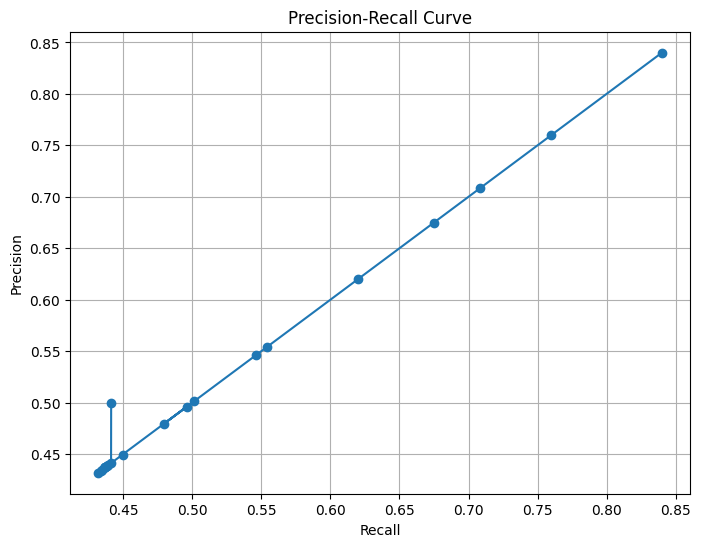

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df['recall'], df['precision'], marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

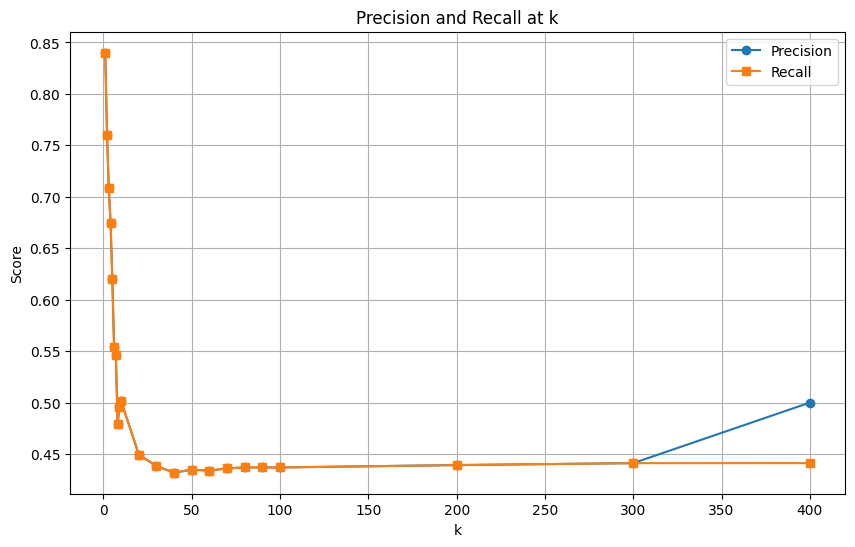

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['precision'], marker='o', label='Precision')
plt.plot(df.index, df['recall'], marker='s', label='Recall')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Precision and Recall at k')
plt.legend()
plt.grid(True)
plt.show()

<Axes: xlabel='k'>

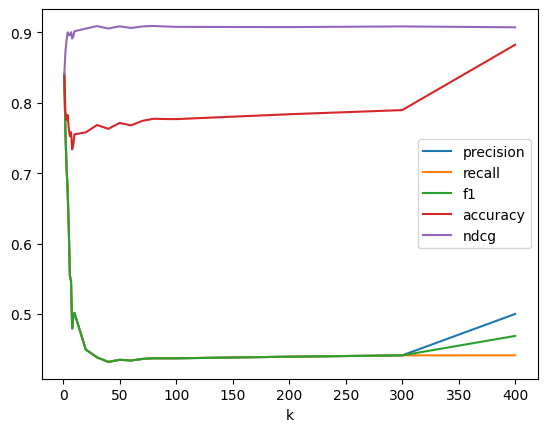

In [ ]:
df.plot()

k
1     Axes(0.125,0.11;0.775x0.77)
2     Axes(0.125,0.11;0.775x0.77)
3     Axes(0.125,0.11;0.775x0.77)
4     Axes(0.125,0.11;0.775x0.77)
5     Axes(0.125,0.11;0.775x0.77)
6     Axes(0.125,0.11;0.775x0.77)
7     Axes(0.125,0.11;0.775x0.77)
8     Axes(0.125,0.11;0.775x0.77)
9     Axes(0.125,0.11;0.775x0.77)
10    Axes(0.125,0.11;0.775x0.77)
dtype: object

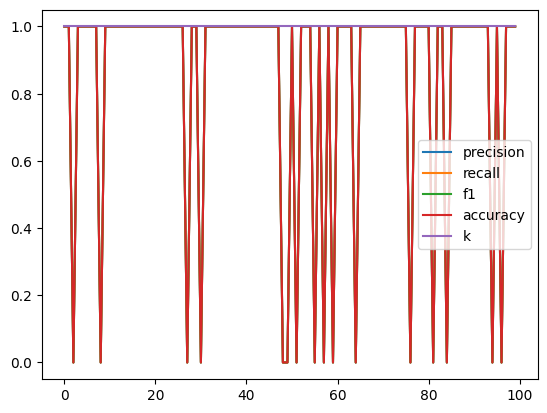

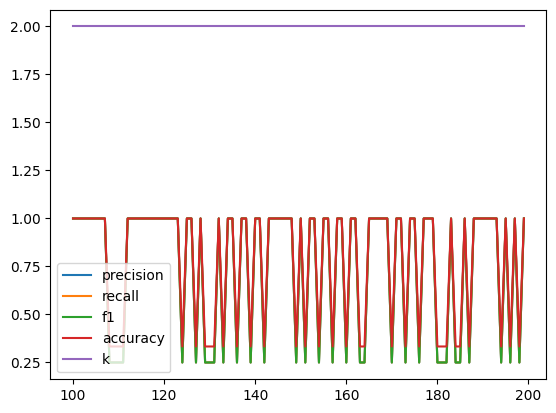

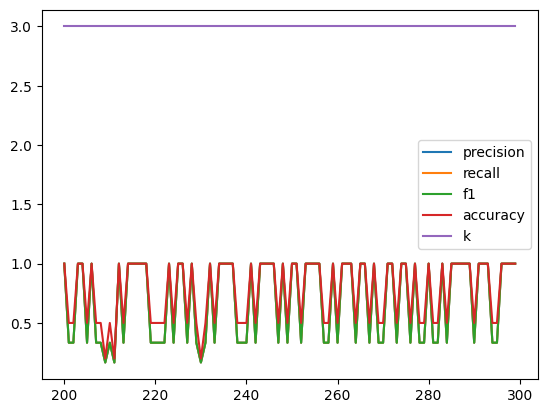

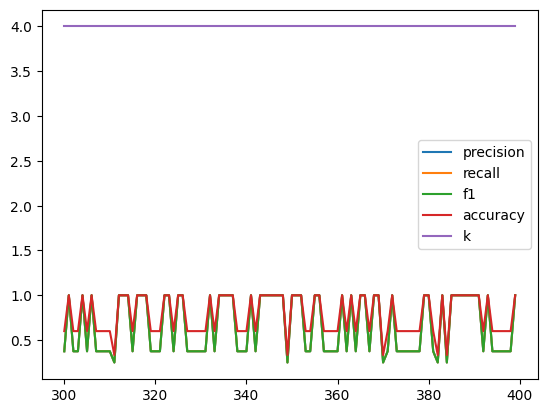

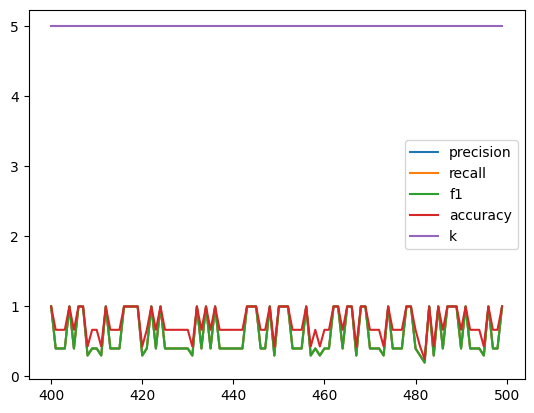

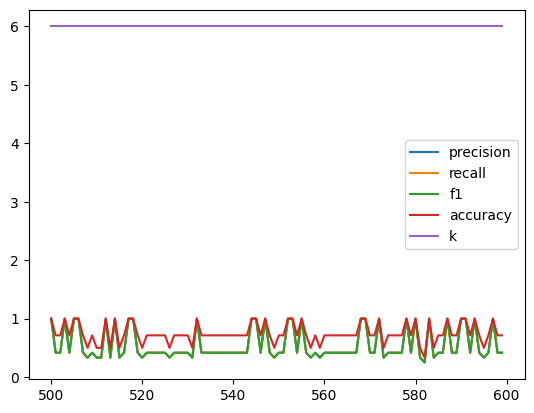

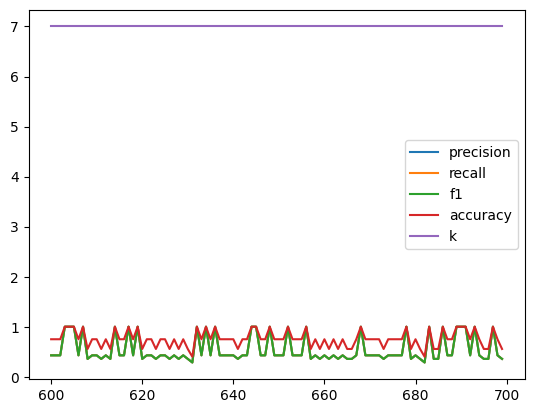

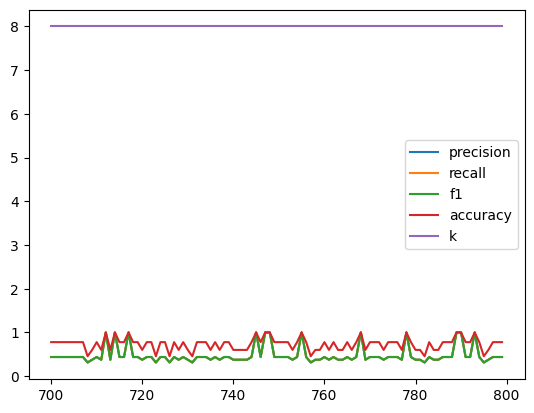

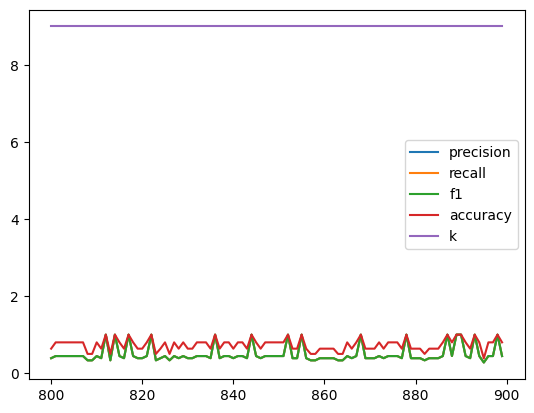

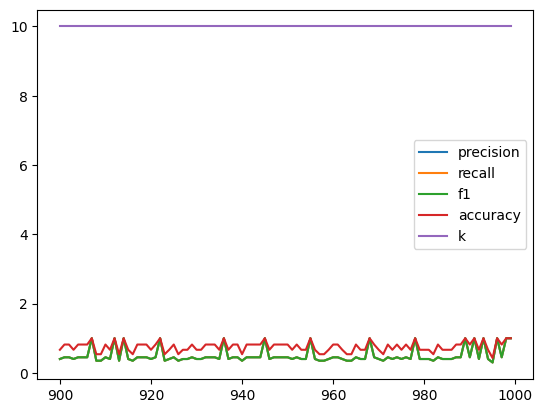

In [ ]:
df.plot()

In [ ]:
import numpy as np

def rowwise_recall(full: np.ndarray, coreset: np.ndarray) -> np.ndarray:
    k = full.shape[1]
    recall = np.array([
        len(set(f) & set(c)) / k
        for f, c in zip(full, coreset)
    ])
    return recall
recalls = rowwise_recall(full, coreset)
print("Average Recall:", recalls.mean())

In [ ]:
estimators[1].influence_estimate

In [ ]:
import itertools


In [ ]:
import numpy as np
from scipy import stats
import itertools
import pandas as pd




n_test = estimators[0].influence_estimate.shape[0]
pairwise_results = []
estimator_names = [est.get_config_string() for est in estimators]
for (i, est1), (j, est2) in itertools.combinations(enumerate(estimators), 2):
    corrs = []
    for t in range(n_test):
        corr = stats.spearmanr(est1.influence_estimate[t], est2.influence_estimate[t]).correlation
        corrs.append(corr)
    mean_corr = np.mean(corrs)
    pairwise_results.append({
        "Estimator a": est1.get_config_string(),
        "Estimator b": est2.get_config_string(),
        "Mean Spearman Corr": mean_corr
    })


results_df = pd.DataFrame(pairwise_results)
results_df


In [ ]:
matrix_df = pd.DataFrame(
    np.eye(len(estimators)),  # start with identity for diagonal = 1.0
    index=estimator_names,
    columns=estimator_names,
    dtype=float
)

for _, row in results_df.iterrows():
    a, b, corr = row["Estimator a"], row["Estimator b"], row["Mean Spearman Corr"]
    matrix_df.loc[a, b] = corr
    matrix_df.loc[b, a] = corr


plt.figure(figsize=(8, 6))
sns.heatmap(matrix_df, annot=True,  vmin=0, vmax=1, square=True)
plt.title("Mean Spearman Correlation Between Influence Estimators")
plt.tight_layout()
plt.show()

matrix_df


In [ ]:
estimator_less = estimators[0]
estimator_datainf = estimators[1]#DataInfEstimator(base_model_path, adapter_path, train_dataset, test_dataset,fast_implementation=True)
correlations = np.array([
    stats.spearmanr(estimator_datainf.influence_estimate[i], estimator_less.influence_estimate[i]).correlation for i in range(estimator_less.influence_estimate.shape[0])
])
df = pd.DataFrame({
    "Spearman Correlation": correlations,
    "Comparison": ["LESS vs DataInf"] * len(correlations)
})

# Plot using seaborn violinplot
plt.figure(figsize=(6, 4))
sns.violinplot(data=df, x="Comparison", y="Spearman Correlation", inner="point")
plt.title("Spearman Correlation of Influence Estimates")
plt.ylim(-1.05, 1.05)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
estimator_less.influence_estimate

In [ ]:
estimator_datainf.influence_estimate